### Energy Calibration

The digitizers records pulse heights in arbitrary units called "channels". To perform physics analysis, we must convert these channels into energy units (kilo-electron volts, keV, or mega-electron volts, MeV). This is done using a calibration function, which is typically a linear fit obtained by measuring sources with known energies (like 137Cs, 60Co, 22Na, etc.).

This note book can be used to be fits to peaks in spectra. Use the first cell to plot the spectrum to find relevant peaks to fit. Use the second cell to fit peaks to a gaussian function.

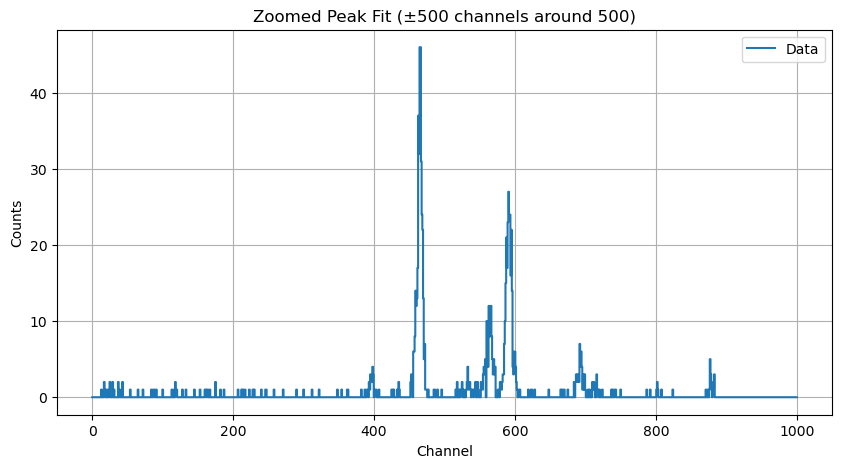

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import numpy as np

def read_mca_file(filename, n_channels=2048):
    with open(filename, 'r', encoding='latin1') as f:
        # Skip to data section
        for line in f:
            if line.strip() == '<<DATA>>':
                break

        # Read exactly n_channels values
        data = []
        for _ in range(n_channels):
            line = f.readline()
            if not line:
                raise ValueError(f"Unexpected end of file after reading {len(data)} bins")
            line = line.strip()
            if not line.isdigit():
                raise ValueError(f"Non-integer value encountered: {line}")
            data.append(int(line))

    return np.array(data)

#filename = "../Data/calibration/55Fe-1h.mca"
filename = "55FE.mca"
counts = read_mca_file(filename)

mu = 2048/2  # or whatever your central channel is
window = 2048/2
plot_range = (mu - window, mu + window)

# Construct x-axis as channel numbers: 0 to len(counts)-1
channels = np.arange(len(counts))

# Apply mask to zoom in around the peak
plot_mask = (channels >= plot_range[0]) & (channels <= plot_range[1])
x_plot = channels[plot_mask]
y_plot = counts[plot_mask]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, drawstyle='steps-mid', label='Data')
plt.title(f'Zoomed Peak Fit (±{window} channels around {mu})')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.show()


Now provide lower limit and upper limit for fit as well as guesses for the sigma and peak position.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === USER SETTINGS ===
fit_min = 3700         # Min channel to include in fit
fit_max = 3900         # Max channel to include in fit
peak_guess = 3805      # Approx. channel position of peak
sigma_guess = 2

# Set up bin axis (channels)
channels = np.arange(len(counts))
bin_centers = channels.astype(float)  # could skip this

# === Fit model ===
def gauss_lin_bg(x, A, mu, sigma, m, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) / (sigma * np.sqrt(2 * np.pi)) + m * x + c

# === Select data for fit ===
fit_mask = (channels >= fit_min) & (channels <= fit_max)
x_fit = channels[fit_mask]
y_fit = counts[fit_mask]

# === Initial parameter guess ===
A_guess = (np.max(y_fit) - np.min(y_fit)) * 1  # bin width = 1 channel
mu_guess = peak_guess
m_guess = 0  # assume flat background initially
c_guess = np.min(y_fit)
p0 = [A_guess, mu_guess, sigma_guess, m_guess, c_guess]

# === Fit ===
popt, pcov = curve_fit(gauss_lin_bg, x_fit, y_fit, p0=p0, absolute_sigma=True)
A, mu, sigma, m, c = popt
errors = np.sqrt(np.diag(pcov))

# === Derived values ===
area = A
fwhm = 2.355 * sigma

# === Chi-squared calculation ===
y_model = gauss_lin_bg(x_fit, *popt)
residuals = y_fit - y_model
variance = np.where(y_fit > 0, y_fit, 1)
chi2 = np.sum((residuals**2) / variance)
ndof = len(y_fit) - len(popt)
reduced_chi2 = chi2 / ndof if ndof > 0 else np.nan

# === Plot ===
plot_range = (int(mu - 100), int(mu + 100))
x_dense = np.linspace(*plot_range, 1000)
y_dense = gauss_lin_bg(x_dense, *popt)

plot_mask = (channels >= plot_range[0]) & (channels <= plot_range[1])
x_plot = channels[plot_mask]
y_plot = counts[plot_mask]

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, drawstyle='steps-mid', label='Data')
plt.plot(x_dense, y_dense, 'r-', label='Fit (Gaussian + background)')
plt.axvline(mu, color='green', linestyle='--', label='Peak center')
plt.title('Zoomed Peak Fit (±100 channels)')
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.legend()
plt.grid(True)
plt.show()

# === Output ===
print(f"Peak position (mu): {mu:.2f} ± {errors[1]:.2f} channels")
print(f"Peak area: {area:.1f} ± {errors[0]:.1f} counts")
print(f"FWHM: {fwhm:.2f} ± {2.355 * errors[2]:.2f} channels")
print(f"Chi-squared: {chi2:.1f}")
print(f"Degrees of freedom: {ndof}")
print(f"Reduced chi-squared: {reduced_chi2:.2f}")


ValueError: zero-size array to reduction operation maximum which has no identity